# Passenger Flow Prediction using TfL Station Entry and Exit Data

## Data Analytics Coursework 2

### MSc Data Science
### University of Roehampton

This project analyses passenger flow patterns in the London transport network using Transport for London (TfL) data and machine learning techniques.

# Introduction

Passenger flow prediction is important in modern urban transport systems because it helps transport authorities improve planning, reduce congestion, and allocate resources effectively.

This project uses Transport for London (TfL) station entry and exit data to analyse passenger flow patterns across different stations and days of the week.

Machine learning models such as Linear Regression and Random Forest Regression are used to predict annualised passenger flow based on daily passenger entry variables.

The aim of this project is to compare machine learning approaches and evaluate their effectiveness in predicting passenger flow.

# Import Libraries

The following libraries were imported for data manipulation, visualisation, and machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
df = pd.read_excel("AC2022_AnnualisedEntryExit.xlsx", header=[5,6])

# Initial Data Exploration

The first few rows and column names were inspected to understand the structure of the dataset.

In [3]:
df.head()

,Unnamed: 0_level_0,Unnamed: 1_level_0,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,Unnamed: 5_level_0,Monday,Midweek (Tue-Thu),Friday,Saturday,Sunday,Monday,Midweek (Tue-Thu),Friday,Saturday,Sunday,Weekly,12-week,Annualised
,Mode,MNLC,MASC,Station,Coverage,Source,Entries,Entries,Entries,Entries,Entries,Exits,Exits,Exits,Exits,Exits,En/Ex,En/Ex,En/Ex
0,LU,500,ACTu,Acton Town,Station entry/exit,Gateline,7304.888889,8194.000000,7973.444444,7211.000000,4661.500000,7443.888889,8169.555556,7995.777778,8128.800000,4991.000000,104800.966667,1.257612e+06,4.931972e+06
1,LU,502,ALDu,Aldgate,Station entry/exit,Gateline,10032.666667,12378.444444,9332.375000,6280.000000,5242.142857,11065.000000,14274.300000,11336.333333,7702.600000,5723.857143,146673.208333,1.760078e+06,6.902494e+06
2,LU,503,ALEu,Aldgate East,Station entry/exit,Gateline,15100.500000,17401.777778,17181.250000,15537.250000,12077.000000,14179.500000,16538.222222,16344.250000,14430.750000,10699.000000,217369.500000,2.608434e+06,1.022949e+07
3,LU,505,ALPu,Alperton,Station entry/exit,Gateline,3692.750000,3734.400000,3746.375000,3024.000000,2214.333333,3950.125000,3923.500000,3948.875000,3066.250000,2320.166667,48936.575000,5.872389e+05,2.302973e+06
4,LU,506,AMEu,Amersham,Station entry/exit,Gateline,2614.237336,3129.301803,2479.048755,2194.104952,1203.456752,2518.905521,3043.253752,2509.395689,2022.495048,1153.793248,35213.103968,4.225572e+05,1.657141e+06


In [4]:
df.columns

MultiIndex([('Unnamed: 0_level_0',     'Mode'),
            ('Unnamed: 1_level_0',     'MNLC'),
            ('Unnamed: 2_level_0',     'MASC'),
            ('Unnamed: 3_level_0',  'Station'),
            ('Unnamed: 4_level_0', 'Coverage'),
            ('Unnamed: 5_level_0',   'Source'),
            (            'Monday',  'Entries'),
            ( 'Midweek (Tue-Thu)',  'Entries'),
            (            'Friday',  'Entries'),
            (          'Saturday',  'Entries'),
            (            'Sunday',  'Entries'),
            (            'Monday',    'Exits'),
            ( 'Midweek (Tue-Thu)',    'Exits'),
            (            'Friday',    'Exits'),
            (          'Saturday',    'Exits'),
            (            'Sunday',    'Exits'),
            (            'Weekly',    'En/Ex'),
            (           '12-week',    'En/Ex'),
            (        'Annualised',    'En/Ex')],
           )

# Data Cleaning

The original dataset contained multi-level column names and special characters. The column names were cleaned to improve readability and simplify analysis in Python.

In [5]:
df.columns = [
    "_".join([str(x) for x in col if "Unnamed" not in str(x)]).strip()
    for col in df.columns
]

In [6]:
df.columns

Index(['Mode', 'MNLC', 'MASC', 'Station', 'Coverage', 'Source',
       'Monday_Entries', 'Midweek (Tue-Thu)_Entries', 'Friday_Entries',
       'Saturday_Entries', 'Sunday_Entries', 'Monday_Exits',
       'Midweek (Tue-Thu)_Exits', 'Friday_Exits', 'Saturday_Exits',
       'Sunday_Exits', 'Weekly_En/Ex', '12-week_En/Ex', 'Annualised_En/Ex'],
      dtype='str')

In [7]:
df.head()

,Mode,MNLC,MASC,Station,Coverage,Source,Monday_Entries,Midweek (Tue-Thu)_Entries,Friday_Entries,Saturday_Entries,Sunday_Entries,Monday_Exits,Midweek (Tue-Thu)_Exits,Friday_Exits,Saturday_Exits,Sunday_Exits,Weekly_En/Ex,12-week_En/Ex,Annualised_En/Ex
0,LU,500,ACTu,Acton Town,Station entry/exit,Gateline,7304.888889,8194.000000,7973.444444,7211.000000,4661.500000,7443.888889,8169.555556,7995.777778,8128.800000,4991.000000,104800.966667,1.257612e+06,4.931972e+06
1,LU,502,ALDu,Aldgate,Station entry/exit,Gateline,10032.666667,12378.444444,9332.375000,6280.000000,5242.142857,11065.000000,14274.300000,11336.333333,7702.600000,5723.857143,146673.208333,1.760078e+06,6.902494e+06
2,LU,503,ALEu,Aldgate East,Station entry/exit,Gateline,15100.500000,17401.777778,17181.250000,15537.250000,12077.000000,14179.500000,16538.222222,16344.250000,14430.750000,10699.000000,217369.500000,2.608434e+06,1.022949e+07
3,LU,505,ALPu,Alperton,Station entry/exit,Gateline,3692.750000,3734.400000,3746.375000,3024.000000,2214.333333,3950.125000,3923.500000,3948.875000,3066.250000,2320.166667,48936.575000,5.872389e+05,2.302973e+06
4,LU,506,AMEu,Amersham,Station entry/exit,Gateline,2614.237336,3129.301803,2479.048755,2194.104952,1203.456752,2518.905521,3043.253752,2509.395689,2022.495048,1153.793248,35213.103968,4.225572e+05,1.657141e+06


## Cleaning Column Names

The column names were further cleaned by replacing spaces and special characters with underscores. This makes the variables easier to select during analysis and modelling.

In [8]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "", regex=False)
df.columns = df.columns.str.replace(")", "", regex=False)
df.columns = df.columns.str.replace("/", "_", regex=False)
df.columns = df.columns.str.replace("-", "_", regex=False)

df.columns

Index(['Mode', 'MNLC', 'MASC', 'Station', 'Coverage', 'Source',
       'Monday_Entries', 'Midweek_Tue_Thu_Entries', 'Friday_Entries',
       'Saturday_Entries', 'Sunday_Entries', 'Monday_Exits',
       'Midweek_Tue_Thu_Exits', 'Friday_Exits', 'Saturday_Exits',
       'Sunday_Exits', 'Weekly_En_Ex', '12_week_En_Ex', 'Annualised_En_Ex'],
      dtype='str')

## Dataset Shape and Information

The shape and structure of the dataset were explored to understand the number of rows, columns, and data types available for analysis.

In [9]:
df.shape

(470, 19)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Mode                     470 non-null    str    
 1   MNLC                     470 non-null    int64  
 2   MASC                     470 non-null    str    
 3   Station                  470 non-null    str    
 4   Coverage                 470 non-null    str    
 5   Source                   470 non-null    str    
 6   Monday_Entries           470 non-null    float64
 7   Midweek_Tue_Thu_Entries  470 non-null    float64
 8   Friday_Entries           470 non-null    float64
 9   Saturday_Entries         470 non-null    float64
 10  Sunday_Entries           470 non-null    float64
 11  Monday_Exits             470 non-null    float64
 12  Midweek_Tue_Thu_Exits    470 non-null    float64
 13  Friday_Exits             470 non-null    float64
 14  Saturday_Exits           470 non-null

In [11]:
df.describe()

,MNLC,Monday_Entries,Midweek_Tue_Thu_Entries,Friday_Entries,Saturday_Entries,Sunday_Entries,Monday_Exits,Midweek_Tue_Thu_Exits,Friday_Exits,Saturday_Exits,Sunday_Exits,Weekly_En_Ex,12_week_En_Ex,Annualised_En_Ex
count,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,4.700000e+02,4.700000e+02,4.700000e+02
mean,1760.289362,8173.017289,9582.825769,8964.971162,8031.277404,5470.166809,8228.664837,9657.221948,9030.079846,8024.001431,5495.249293,1.191376e+05,1.429651e+06,5.596808e+06
std,2242.204848,12407.419425,15315.232623,14042.145389,13671.004519,9467.124394,12714.395630,15704.334153,14508.551449,13947.955526,9546.517684,1.910434e+05,2.292521e+06,8.988379e+06
min,500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,608.250000,2475.084815,2609.694087,2455.232662,1951.562862,1296.530064,2321.060536,2609.697917,2450.520833,1862.900000,1312.844972,3.152214e+04,3.782657e+05,1.490747e+06
50%,719.000000,4358.642654,4996.954167,4781.000000,4030.430958,2773.608820,4367.388889,4842.325000,4634.555556,3853.400000,2699.026786,6.106412e+04,7.327695e+05,2.873257e+06
75%,1082.750000,8402.916667,9605.812500,9292.125000,7859.250000,5354.910714,8520.527618,9755.268750,9204.523810,7808.050000,5529.465987,1.204840e+05,1.445808e+06,5.535700e+06
max,9846.000000,94212.104513,123889.481805,112194.333333,115395.400000,87605.750000,100429.523369,131351.668874,115850.500000,116084.800000,89077.750000,1.486092e+06,1.783311e+07,6.993605e+07


## Missing Values Check

Missing values were checked to confirm whether the dataset required imputation or removal of incomplete records.

In [12]:
df.isnull().sum()

Mode                       0
MNLC                       0
MASC                       0
Station                    0
Coverage                   0
Source                     0
Monday_Entries             0
Midweek_Tue_Thu_Entries    0
Friday_Entries             0
Saturday_Entries           0
Sunday_Entries             0
Monday_Exits               0
Midweek_Tue_Thu_Exits      0
Friday_Exits               0
Saturday_Exits             0
Sunday_Exits               0
Weekly_En_Ex               0
12_week_En_Ex              0
Annualised_En_Ex           0
dtype: int64

The missing values check shows that all columns contain zero missing values. Therefore, no imputation or row removal was required before modelling.

## Distribution of Annualised Passenger Flow

A histogram was used to examine how annualised passenger flow is distributed across stations.

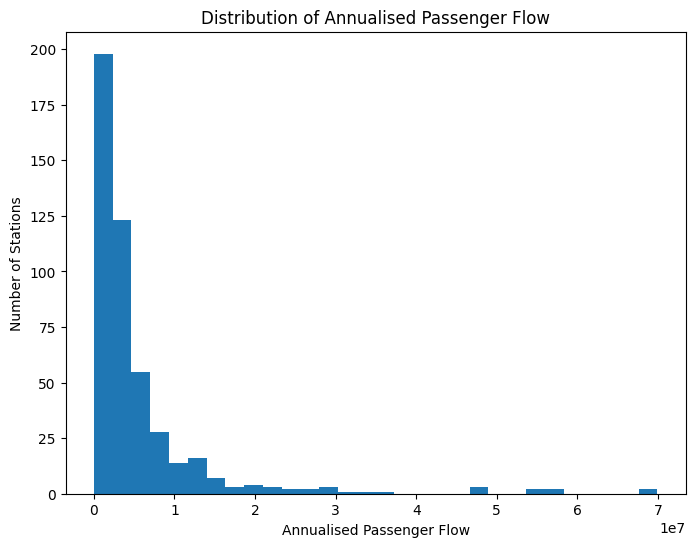

In [13]:
plt.figure(figsize=(8, 6))
plt.hist(df["Annualised_En_Ex"], bins=30)
plt.xlabel("Annualised Passenger Flow")
plt.ylabel("Number of Stations")
plt.title("Distribution of Annualised Passenger Flow")
plt.show()

The histogram shows that annualised passenger flow is right-skewed. Most stations have relatively low passenger flow, while a small number of stations have very high passenger flow. This suggests that passenger demand is not evenly distributed across the TfL network.

## Boxplot of Annualised Passenger Flow

A boxplot was used to identify the spread of the data and detect possible outliers in annualised passenger flow.

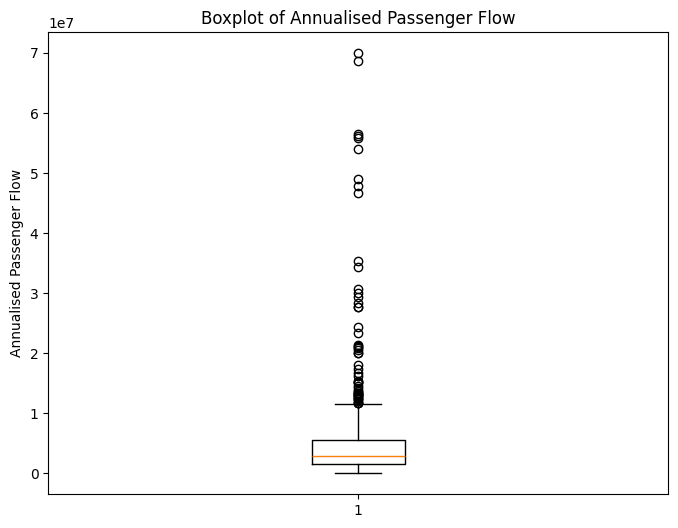

In [14]:
plt.figure(figsize=(8, 6))

plt.boxplot(df["Annualised_En_Ex"])

plt.ylabel("Annualised Passenger Flow")

plt.title("Boxplot of Annualised Passenger Flow")

plt.show()

The boxplot shows several outliers in annualised passenger flow. These outliers represent stations with much higher passenger demand compared to most stations in the dataset. This suggests that passenger flow is unevenly distributed across the TfL network, with a small number of stations handling very large passenger volumes.

## Correlation Analysis

Correlation analysis was performed to examine the relationships between passenger flow variables and annualised passenger flow.

In [15]:
correlation = df.corr(numeric_only=True)

correlation["Annualised_En_Ex"].sort_values(ascending=False)

Annualised_En_Ex           1.000000
Weekly_En_Ex               0.999932
12_week_En_Ex              0.999932
Friday_Exits               0.997436
Friday_Entries             0.997213
Monday_Entries             0.995620
Midweek_Tue_Thu_Entries    0.994337
Monday_Exits               0.994301
Midweek_Tue_Thu_Exits      0.992625
Saturday_Exits             0.972008
Saturday_Entries           0.971049
Sunday_Exits               0.963846
Sunday_Entries             0.958668
MNLC                      -0.152922
Name: Annualised_En_Ex, dtype: float64

The correlation results show that most passenger flow variables have a very strong positive relationship with annualised passenger flow. This means that stations with higher daily or weekly passenger counts also tend to have higher annualised passenger flow.

The very high correlations also suggest that annualised passenger flow is closely connected to the daily and weekly passenger measurements in the dataset.

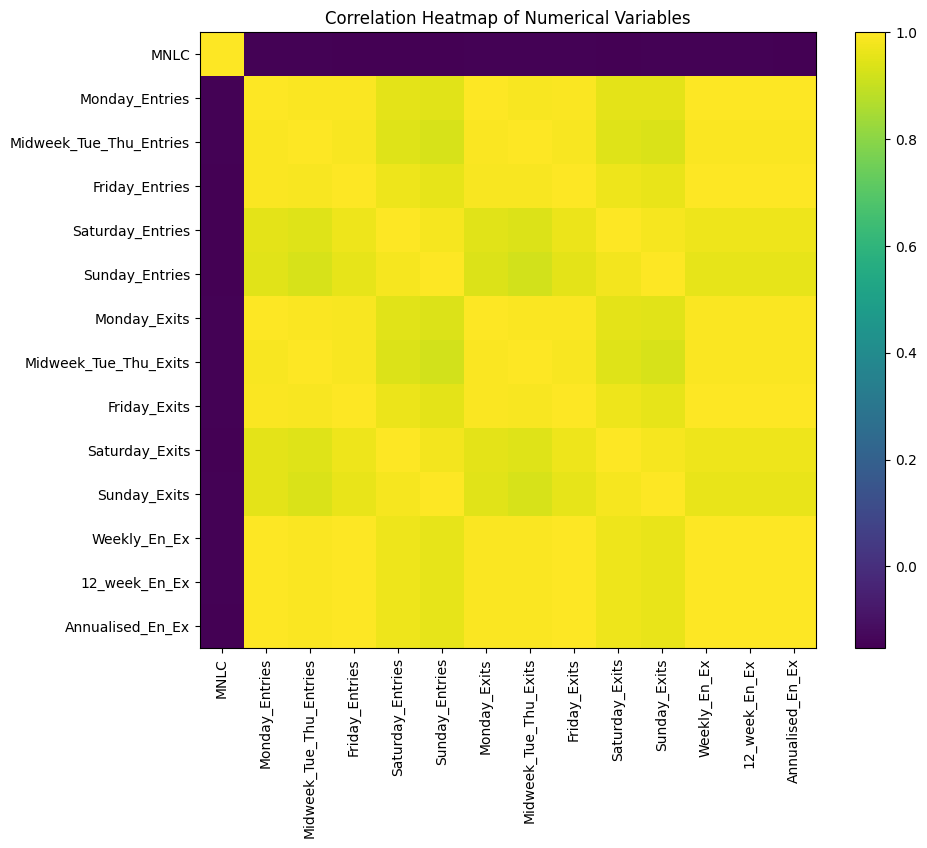

In [16]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

The heatmap shows strong positive correlations between most passenger flow variables. Lighter colours indicate stronger relationships, meaning stations with high passenger entries or exits on one day also tend to have high passenger flow on other days.

The MNLC variable shows weak correlation with passenger flow because it represents a station identification code rather than passenger activity.

## Skewness Analysis

Skewness was calculated to understand whether the numerical variables were normally distributed or skewed. This is important because highly skewed data may indicate the presence of extreme values or uneven passenger demand across stations.

In [17]:
df.skew(numeric_only=True).sort_values(ascending=False)

Sunday_Exits               4.644413
Sunday_Entries             4.642246
Saturday_Entries           4.359061
Saturday_Exits             4.308635
Friday_Exits               4.212534
Midweek_Tue_Thu_Exits      4.211838
Friday_Entries             4.155371
Annualised_En_Ex           4.154582
12_week_En_Ex              4.149006
Weekly_En_Ex               4.149006
Midweek_Tue_Thu_Entries    4.146813
Monday_Exits               4.099298
Monday_Entries             4.030382
MNLC                       1.841487
dtype: float64

The skewness values are strongly positive for most passenger flow variables. This confirms that the data is right-skewed, meaning most stations have relatively low passenger flow while a small number of stations have very high passenger flow. This supports the findings from the histogram and boxplot.

## Feature Selection

The features selected for modelling include both passenger entries and exits across different days of the week. These variables were selected because they represent passenger movement patterns and are strongly related to annualised passenger flow.

The target variable is `Annualised_En_Ex`, which represents the annualised passenger flow.

In [18]:
X = df[[
    "Monday_Entries",
    "Midweek_Tue_Thu_Entries",
    "Friday_Entries",
    "Saturday_Entries",
    "Sunday_Entries",
    "Monday_Exits",
    "Midweek_Tue_Thu_Exits",
    "Friday_Exits",
    "Saturday_Exits",
    "Sunday_Exits"
]]

y = df["Annualised_En_Ex"]

X.head()

,Monday_Entries,Midweek_Tue_Thu_Entries,Friday_Entries,Saturday_Entries,Sunday_Entries,Monday_Exits,Midweek_Tue_Thu_Exits,Friday_Exits,Saturday_Exits,Sunday_Exits
0,7304.888889,8194.000000,7973.444444,7211.000000,4661.500000,7443.888889,8169.555556,7995.777778,8128.800000,4991.000000
1,10032.666667,12378.444444,9332.375000,6280.000000,5242.142857,11065.000000,14274.300000,11336.333333,7702.600000,5723.857143
2,15100.500000,17401.777778,17181.250000,15537.250000,12077.000000,14179.500000,16538.222222,16344.250000,14430.750000,10699.000000
3,3692.750000,3734.400000,3746.375000,3024.000000,2214.333333,3950.125000,3923.500000,3948.875000,3066.250000,2320.166667
4,2614.237336,3129.301803,2479.048755,2194.104952,1203.456752,2518.905521,3043.253752,2509.395689,2022.495048,1153.793248


## Train-Test Split

The dataset was divided into training and testing sets before model development. The training set was used to train the machine learning models, while the testing set was used to evaluate model performance on unseen data.

An 80:20 split was applied, meaning 80% of the data was used for training and 20% was reserved for testing. A random state of 42 was used to ensure reproducibility of the results.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((376, 10), (94, 10))

## Linear Regression Model

Linear Regression was used as the first predictive model to estimate annualised passenger flow based on daily passenger entries and exits. The model was trained using the training dataset and evaluated using the testing dataset.

In [20]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

r2 = r2_score(y_test, y_pred_linear)

mae = mean_absolute_error(y_test, y_pred_linear)

r2, mae

(0.9997130711880483, 59764.89624586715)

The Linear Regression model achieved an R² score of 0.9997 and a Mean Absolute Error of approximately 59,764. This indicates that the model explains most of the variation in annualised passenger flow and makes predictions with relatively low average error.

## Random Forest Regression Model

Random Forest Regression was used as an alternative model to compare against Linear Regression. Unlike Linear Regression, Random Forest can capture more complex non-linear relationships by combining multiple decision trees.

In [21]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)

mae_rf = mean_absolute_error(y_test, y_pred_rf)

r2_rf, mae_rf

(0.9975566365745453, 209405.22406997313)

The Random Forest model achieved an R² score of 0.9975 and a Mean Absolute Error of approximately 209,405. Although this model also performed well, its error was higher than the Linear Regression model.

## Model Comparison

In [22]:
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [r2, r2_rf],
    "MAE": [mae, mae_rf]
})

model_results

,Model,R2 Score,MAE
0,Linear Regression,0.999713,59764.896246
1,Random Forest,0.997557,209405.224070


The comparison table shows that Linear Regression performed better than Random Forest. Linear Regression had a slightly higher R² score and a much lower MAE. This suggests that the relationship between the selected passenger flow variables and annualised passenger flow is mostly linear.

## Feature Importance Analysis

Feature importance was used to identify which input variables had the strongest influence on the Random Forest model prediction.

In [23]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
7,Friday_Exits,0.205503
2,Friday_Entries,0.161522
1,Midweek_Tue_Thu_Entries,0.143430
5,Monday_Exits,0.110767
9,Sunday_Exits,0.105568
6,Midweek_Tue_Thu_Exits,0.089147
0,Monday_Entries,0.088577
4,Sunday_Entries,0.070986
8,Saturday_Exits,0.013324
3,Saturday_Entries,0.011178


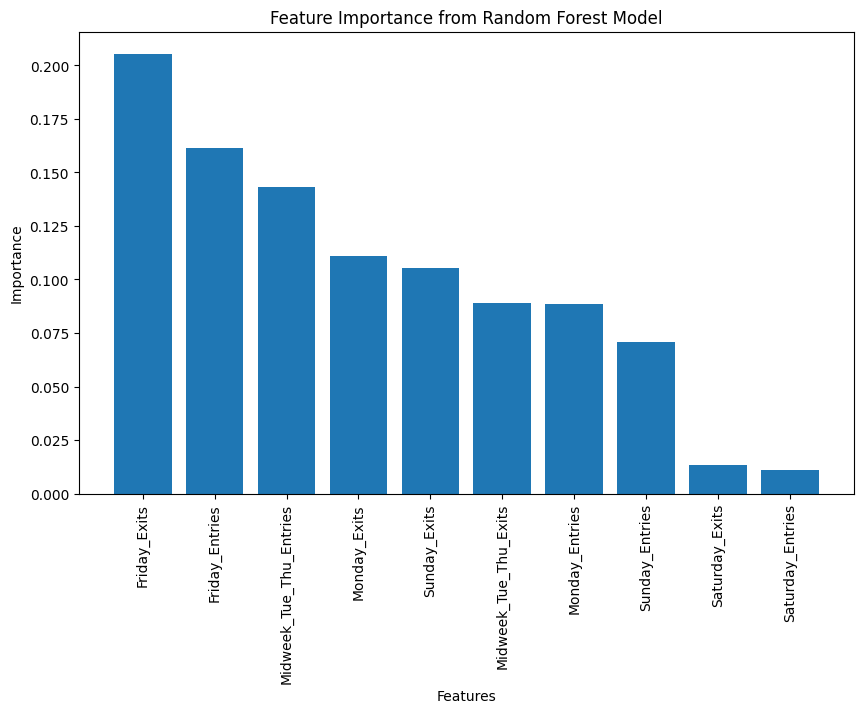

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance from Random Forest Model")
plt.show()

The feature importance chart shows that Friday_Exits, Friday_Entries, and Midweek_Tue_Thu_Entries had the strongest influence on the Random Forest model. This suggests that weekday passenger movement, especially Friday and midweek travel, contributes strongly to predicting annualised passenger flow.

## Prediction Visualisation

A scatter plot was used to compare the actual annualised passenger flow values with the predicted values from the Linear Regression model.

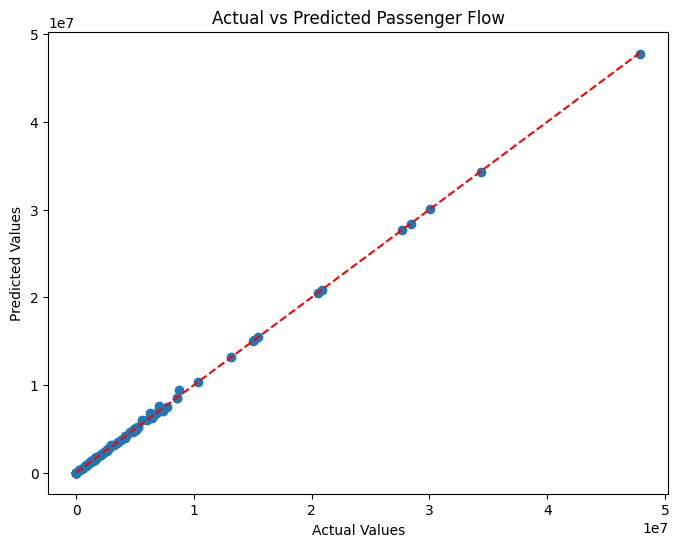

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Passenger Flow")

plt.show()

The prediction visualisation shows that most points are close to the red dashed line, which represents perfect prediction. This means the Linear Regression model predicted annualised passenger flow very closely to the actual values.

## Limitations

Although the models achieved high accuracy, the results should be interpreted carefully. The target variable, annualised passenger flow, is closely related to the daily entry and exit variables used as features. This may explain why the model performance is very high.

The analysis also does not include external factors such as weather, special events, service disruptions, or population changes, which could affect passenger flow in real life.

## Conclusion

This project analysed TfL station entry and exit data to understand and predict annualised passenger flow. Exploratory data analysis showed that passenger flow is right-skewed, with a small number of stations handling very high passenger volumes.

Linear Regression and Random Forest models were applied. Linear Regression performed better, achieving a higher R² score and lower MAE. Overall, the analysis shows that daily passenger flow variables are strong predictors of annualised passenger flow.